# Berenice — Solver 2D linearizzato con convezione

Ispirato a `GLY_LUD_2D_convection (2)Stefano.ipynb`, ma con **equazioni linearizzate** intorno allo stato base 1D.

**Strategia:**
1. Pre-calcola lo stato base 1D: $\bar{c}(z,t)$, $\bar{\phi}(z,t)$ (pura diffusione, senza flusso)
2. Risolve le equazioni linearizzate 2D per le perturbazioni $c'$, $\phi'$, $\mathbf{u}'$, $p'$

**Equazioni linearizzate:**

$$\nabla \cdot \mathbf{u}' = 0$$

$$\partial_t \mathbf{u}' - \nu \nabla^2 \mathbf{u}' + \nabla p'/\rho_{ref} = -g \frac{\rho_c \, c' + \rho_\phi \, \phi'}{\rho_{ref}} \, \hat{e}_z$$

$$\partial_t c' - D_g^{ref} \nabla^2 c' = -w' \, \partial_z \bar{c} + \nabla \cdot [(D_g(\bar{c}) - D_g^{ref}) \nabla c']$$

$$\partial_t \phi' - D_c^{ref} \nabla^2 \phi' = -w' \, \partial_z \bar{\phi} + \nabla \cdot [(D_c(\bar{c}) - D_c^{ref}) \nabla \phi'] + \nabla \cdot [\bar{B} \nabla c'] + \nabla \cdot [Q \, \phi' \hat{e}_z]$$

Dove:
- $\rho_c = \partial\rho/\partial c|_{\bar{c},\bar{\phi}} = \gamma(1-\bar{\phi})$
- $\rho_\phi = \partial\rho/\partial\phi|_{\bar{c},\bar{\phi}} = (\rho_{Lu}-\rho_w) - \gamma \bar{c}$
- $\bar{B} = (\alpha/\rho_w) D_c(\bar{c}) \, \bar{\phi} \, (\rho_w + 2\gamma\bar{c})$
- $Q = (\alpha/\rho_w) D_c(\bar{c}) (\rho_w + 2\gamma\bar{c}) \, \partial_z\bar{c}$

**Niente termine** $\mathbf{u}' \cdot \nabla \mathbf{u}'$ nel momento (sistema lineare).

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import dedalus.public as d3

try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12})

## 1. Parametri

In [16]:
# Geometria (cm)
Lz_cm = 0.1
Lx_cm = 1.0
z_interface_cm = 0.05
interface_width_cm = 0.1/30  # ≈ 0.00333 cm, come V1 (h/30)

# Risoluzione !!!STEFANO USA Nx=1000 e Nz=500 e dealias =1(vedi Cassandra)
Nx = 50
Nz = 25
dealias = 1.0

# Tempo stefano diverso, guarda cassandra
dt = 0.00125         # [s]
t_end = 1000.0     # [s]
PRE_INSTABILITY_MARGIN_S = 100.0  # [s] margine prima della soglia Ra=1 da cui far partire il solver 2D
save_every = 100   # salva ogni N step

# Condizioni iniziali
c0   = 0.40
phi0 = 0.01
noise_amp  = 1e-4
noise_seed = 42

# Parametri fisici (identici a Stefano / MATLAB)
alpha     = 125.0
rho_w     = 997.0
rho_Lu    = 2200.0
gamma_b   = 230.0    # chiamato gamma_b per evitare conflitto con Python gamma
Kb        = 1.38e-23
Temp      = 25 + 273.15
Tc        = Temp - 273.15
r_particle = 11e-9

# Fluidodinamica Boussinesq
g_acc    = 9.8     # [m/s^2]
g_cm     = 980.0   # [cm/s^2]
rho_ref  = rho_w
nu_ref   = 0.01    # [cm^2/s]

# Numero di Rayleigh critico
Ra_thres  = 27*np.pi**4/4
muDc_phys = Kb*Temp/(6*np.pi*r_particle)  # [m^3/s] usato per Ra

print(f'c0={c0}, phi0={phi0}, alpha={alpha}')
print(f'Griglia: Nx={Nx}, Nz={Nz}, dt={dt}s, t_end={t_end}s')

c0=0.4, phi0=0.01, alpha=125.0
Griglia: Nx=50, Nz=25, dt=0.00125s, t_end=1000.0s


## 2. Funzioni costitutive

In [17]:
def rho_solvent(c):     #calcola la densità del solvente (acqua+glicerolo) in funzione della concentrazione di glicerolo
    return rho_w + gamma_b * c

def D_glycerol(c):      #Coeff di diff del glicerolo (come STEFANO)
    """Ds(c) in cm^2/s."""
    return (10.25 - 13.08*c) * 1e-6

def viscosity_gly_water(c):   #come Stefano calcola la viscosità dinamica della miscela acqua-glicerolo  usando la correlaz empirica di Cheng (2008) per miscele di glicerolo e acqua
    c = np.clip(c, 1e-9, 0.999999) #evita valori esattamente 0 o 1 che manderebbero in errore le formule
    a, b = 0.705, 2.0
    mu_alpha = 1 - c + (a*b*c*(1-c))/(a*c + b*(1-c)) #esponente di mescolamento
    mu_g = 12100*np.exp((-1233+Tc)*Tc/(9900+70*Tc)) #viscosità glicerolo
    mu_w = 1.79 *np.exp((-1230-Tc)*Tc/(36100+360*Tc)) #viscosità acqua 
    return (mu_w**mu_alpha)*(mu_g**(1-mu_alpha))*0.001

def D_ludox(c):
    """Dc(c) in cm^2/s."""
    mu = viscosity_gly_water(c)
    return Kb*Temp/(6*np.pi*mu*r_particle) * 1e4

def density_mixture(c, phi):
    return rho_w + (rho_Lu-rho_w)*phi + gamma_b*(1-phi)*c

# Valori di riferimento a c0
Dg_ref = float(D_glycerol(c0))
Dc_ref = float(D_ludox(c0))
print(f'Dg_ref = {Dg_ref:.3e} cm^2/s')
print(f'Dc_ref = {Dc_ref:.3e} cm^2/s')

2026-07-26 11:34:42,786 asyncio 0/1 ERROR :: Task was destroyed but it is pending!
task: <Task pending name='Task-265' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/alicevullo/miniforge3/envs/tesi/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-266' coro=<Kernel.shell_main() running at /Users/alicevullo/miniforge3/envs/tesi/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/alicevullo/miniforge3/envs/tesi/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
2026-07-26 11:34:42,836 asyncio 0/1 ERROR :: Task was destroyed but it is pending!
task: <Task pending name='Task-266' coro=<Kernel.shell_main() running at /Users/alicevullo/miniforge3/envs/tesi/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Dg_ref = 5.018e-06 cm^2/s
Dc_ref = 6.774e-08 cm^2/s


/Users/alicevullo/miniforge3/envs/tesi/lib/python3.11/tokenize.py:529: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)


## 3. Stato base 1D (pura diffusione, senza flusso)

Pre-calcola $\bar{c}(z,t)$ e $\bar{\phi}(z,t)$ risolvendo le equazioni 1D con `scipy.solve_ivp`.
Questo stato base viene poi usato come coefficiente noto nelle equazioni 2D linearizzate.

Calcolo stato base 1D ...
  Completato: 2001 istanti temporali


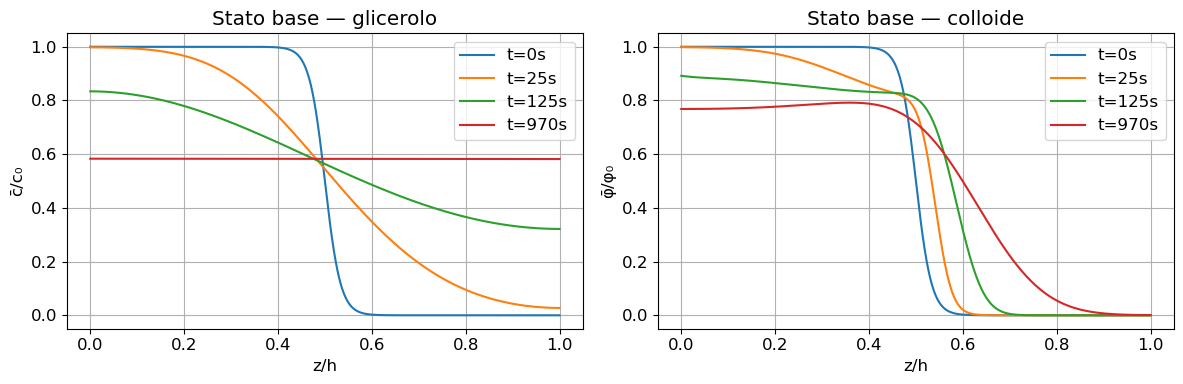


Check max(phi_base/phi0) nel tempo:
  t=0s  max(phi/phi0)=1.0000
  t=100s  max(phi/phi0)=0.9187
  t=200s  max(phi/phi0)=0.8368
  t=300s  max(phi/phi0)=0.8206
  t=400s  max(phi/phi0)=0.8140
  t=500s  max(phi/phi0)=0.8083
  t=600s  max(phi/phi0)=0.8036
  t=700s  max(phi/phi0)=0.7997
  t=800s  max(phi/phi0)=0.7964
  t=900s  max(phi/phi0)=0.7936
  t=1000s  max(phi/phi0)=0.7911


In [18]:
def compute_base_state_1d(t_eval, Nz1d=512):
    """
    Risolve la diffusione 1D per c̄ e φ̄ con metodo delle linee (RK45).
    Formula diffusioforesi identica a V1: Dc_ref costante fuori dalla derivata.
    Ritorna z1d [cm], c_base (Nz1d x Nt), phi_base (Nz1d x Nt), t_out.
    """
    z1d = np.linspace(0, Lz_cm, Nz1d)
    dz  = z1d[1] - z1d[0]

    H0  = 0.5*(1 - np.tanh((z1d - z_interface_cm)/interface_width_cm))
    y0  = np.concatenate([c0*H0, phi0*H0])

    def rhs(t, y):
        c  = np.clip(y[:Nz1d],  0, c0)
        ph = np.clip(y[Nz1d:], 0, None)

        Dg     = D_glycerol(c)
        Dc_loc = D_ludox(c)

        # Laplaciano con BC Neumann (ghost point simmetrico)
        c_ext  = np.r_[c[0],  c,  c[-1]]
        ph_ext = np.r_[ph[0], ph, ph[-1]]
        d2c  = (c_ext[2:]  - 2*c_ext[1:-1]  + c_ext[:-2])  / dz**2
        d2ph = (ph_ext[2:] - 2*ph_ext[1:-1] + ph_ext[:-2]) / dz**2

        # dc/dz con differenze centrali (BC Neumann: dcdz=0 ai bordi)
        dcdz = np.zeros(Nz1d)
        dcdz[1:-1] = (c[2:] - c[:-2]) / (2*dz)

        # Diffusioforesi: (alpha*Dc_ref/rho_w) * d/dz[phi*(rho_w+2*gamma_b*c)*dcdz]
        # Dc_ref costante come in V1 — evita termine spurio da d(Dc)/dz
        cross = ph * (rho_w + 2*gamma_b*c) * dcdz
        dcross = np.zeros(Nz1d)
        dcross[1:-1] = (cross[2:] - cross[:-2]) / (2*dz)

        dphi_dt = Dc_ref*d2ph + (alpha*Dc_ref/rho_w)*dcross

        return np.concatenate([Dg*d2c, dphi_dt])

    print('Calcolo stato base 1D ...')
    sol = solve_ivp(rhs, [0, t_eval[-1]], y0, t_eval=t_eval,
                    method='RK45', rtol=1e-7, atol=1e-10)
    print(f'  Completato: {sol.y.shape[1]} istanti temporali')

    return z1d, sol.y[:Nz1d, :], sol.y[Nz1d:, :], sol.t


# Esegui (ogni 0.5 s)
t_base_eval = np.linspace(0, t_end, int(t_end/0.5)+1)
z1d, c_base, phi_base, t_base = compute_base_state_1d(t_base_eval)

# Visualizza
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for t_show in [0, 25, 125, 970]:
    idx = np.argmin(np.abs(t_base - t_show))
    axes[0].plot(z1d/Lz_cm, c_base[:,idx]/c0,   label=f't={t_base[idx]:.0f}s')
    axes[1].plot(z1d/Lz_cm, phi_base[:,idx]/phi0, label=f't={t_base[idx]:.0f}s')
axes[0].set(xlabel='z/h', ylabel='c̄/c₀', title='Stato base — glicerolo')
axes[1].set(xlabel='z/h', ylabel='φ̄/φ₀', title='Stato base — colloide')
for ax in axes:
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# Check picco diffusioforesi
print("\nCheck max(phi_base/phi0) nel tempo:")
for k in range(0, len(t_base), max(1, len(t_base)//10)):
    print(f"  t={t_base[k]:.0f}s  max(phi/phi0)={phi_base[:,k].max()/phi0:.4f}")

## 4. Numero di Rayleigh dallo stato base

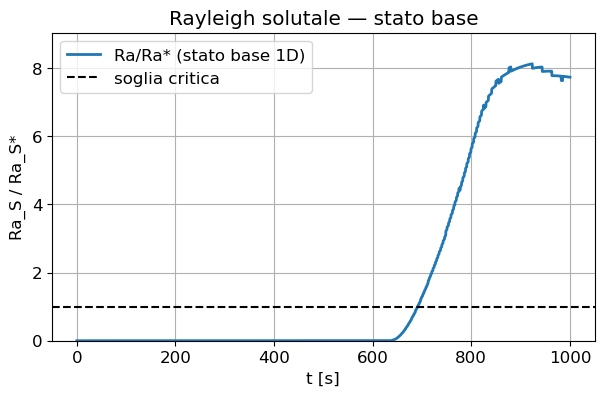

Soglia Ra=1 superata nello stato base a t = 691.0 s
Il solver 2D partira da t_start = 591.0 s (margine di 100 s)


In [19]:
def rayleigh_from_1d(z_m, rho_prof):
    """Calcola Ra/Ra* dal profilo di densità 1D (z in metri)."""
    max_idx, _ = find_peaks(rho_prof)
    min_idx, _ = find_peaks(-rho_prof)
    if len(max_idx) == 0:
        return 0.0
    if len(min_idx) == 0:
        min_idx = np.array([0])
    Dz  = z_m[max_idx][None,:] - z_m[min_idx][:,None]
    Dr  = rho_prof[max_idx][None,:] - rho_prof[min_idx][:,None]
    Ra  = (g_acc/muDc_phys)*(Dz**3)*Dr / Ra_thres
    valid = (Dz > 0) & (Dr > 0)
    return float(np.nanmax(Ra[valid])) if np.any(valid) else 0.0


Ra_base = np.array([
    rayleigh_from_1d(z1d*0.01,
                     density_mixture(c_base[:,k], phi_base[:,k]))
    for k in range(len(t_base))
])

plt.figure(figsize=(7,4))
plt.plot(t_base, Ra_base, lw=2, label='Ra/Ra* (stato base 1D)')
plt.axhline(1, ls='--', c='k', label='soglia critica')
plt.xlabel('t [s]'); plt.ylabel('Ra_S / Ra_S*')
plt.title('Rayleigh solutale — stato base')
plt.ylim(0, max(1.5, float(np.nanmax(Ra_base))*1.1 + 0.1))
plt.legend(); plt.grid(True); plt.show()

# Individua il primo istante in cui lo stato base supera la soglia Ra=1:
# il solver 2D puo' partire PRE_INSTABILITY_MARGIN_S secondi prima,
# risparmiando tempo di calcolo nella fase stabile in cui non succede nulla.
_above = np.where(Ra_base > 1)[0]
if len(_above) > 0:
    t_cross = float(t_base[_above[0]])
    t_start = max(0.0, t_cross - PRE_INSTABILITY_MARGIN_S)
    print(f'Soglia Ra=1 superata nello stato base a t = {t_cross:.1f} s')
    print(f'Il solver 2D partira da t_start = {t_start:.1f} s '
          f'(margine di {PRE_INSTABILITY_MARGIN_S:.0f} s)')
else:
    t_start = 0.0
    print('Soglia Ra=1 non superata nello stato base: il solver 2D partira da t_start = 0 s')


## 5. Solver Dedalus 2D linearizzato

In [20]:
def run_berenice(t_start=0.0): #dentro questa funzione vive tutto il Solver 
    """
    Solver 2D LINEARIZZATO intorno allo stato base (c̄, φ̄).

    IMEX RK222:
      Implicito  : Dg_ref * ∇²c'  e  Dc_ref * ∇²φ'  (coefficienti costanti)
      Esplicito  : tutto il resto (avvezione, correzioni diffusive, diffusioforesi)
    """

    coords = d3.CartesianCoordinates('x', 'z')
    dist   = d3.Distributor(coords, dtype=np.float64)

    xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx_cm), dealias=dealias)
    zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz_cm), dealias=dealias)

    x, z = dist.local_grids(xbasis, zbasis)
    ex, ez = coords.unit_vector_fields(dist)

    (z_ded_raw,) = dist.local_grids(zbasis)
    z_ded = np.asarray(z_ded_raw).ravel()   # (64,) nativa

    # ------------------------------------------------------------------
    # Campi perturbazione (2D)
    # ------------------------------------------------------------------
    p   = dist.Field(name='p',   bases=(xbasis, zbasis))
    c   = dist.Field(name='c',   bases=(xbasis, zbasis))
    phi = dist.Field(name='phi', bases=(xbasis, zbasis))
    u   = dist.VectorField(coords, name='u', bases=(xbasis, zbasis))

    tau_p    = dist.Field(name='tau_p')
    tau_c1   = dist.Field(name='tau_c1',   bases=xbasis)
    tau_c2   = dist.Field(name='tau_c2',   bases=xbasis)
    tau_phi1 = dist.Field(name='tau_phi1', bases=xbasis)
    tau_phi2 = dist.Field(name='tau_phi2', bases=xbasis)
    tau_u1   = dist.VectorField(coords, name='tau_u1', bases=xbasis)
    tau_u2   = dist.VectorField(coords, name='tau_u2', bases=xbasis)

    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)

    grad_c   = d3.grad(c)   + ez*lift(tau_c1)
    grad_phi = d3.grad(phi) + ez*lift(tau_phi1)
    grad_u   = d3.grad(u)   + ez*lift(tau_u1)

    # ------------------------------------------------------------------
    # Campi coefficienti 1D (solo zbasis)
    # ------------------------------------------------------------------
    Dg_bar_f     = dist.Field(name='Dg_bar_f',     bases=zbasis)
    Dc_bar_f     = dist.Field(name='Dc_bar_f',     bases=zbasis)
    B_bar_f      = dist.Field(name='B_bar_f',      bases=zbasis)
    Q_f          = dist.Field(name='Q_f',          bases=zbasis)
    dcdz_bar_f   = dist.Field(name='dcdz_bar_f',   bases=zbasis)
    dphidz_bar_f = dist.Field(name='dphidz_bar_f', bases=zbasis)
    rho_c_f      = dist.Field(name='rho_c_f',      bases=zbasis)
    rho_phi_f    = dist.Field(name='rho_phi_f',    bases=zbasis)

    coeff_fields = [Dg_bar_f, Dc_bar_f, B_bar_f, Q_f,
                    dcdz_bar_f, dphidz_bar_f, rho_c_f, rho_phi_f]

    def update_base_state(t_current):
        t_cur = float(np.clip(t_current, 0, t_base[-1]))
        k = int(np.clip(np.searchsorted(t_base, t_cur), 1, len(t_base)-1))
        alpha_t = (t_cur - t_base[k-1]) / (t_base[k] - t_base[k-1] + 1e-300)

        c_bar_1d   = (1-alpha_t)*c_base[:,k-1] + alpha_t*c_base[:,k]
        phi_bar_1d = (1-alpha_t)*phi_base[:,k-1] + alpha_t*phi_base[:,k]

        c_bar   = np.clip(np.interp(z_ded, z1d, c_bar_1d),   1e-12, c0)
        phi_bar = np.clip(np.interp(z_ded, z1d, phi_bar_1d), 1e-12, phi0)

        dcdz   = np.gradient(c_bar,   z_ded)
        dphidz = np.gradient(phi_bar, z_ded)

        Dg_bar = D_glycerol(c_bar)
        Dc_bar = D_ludox(c_bar)
        B_bar  = (alpha/rho_w)*Dc_bar*phi_bar*(rho_w + 2*gamma_b*c_bar)
        Q      = (alpha/rho_w)*Dc_bar*(rho_w + 2*gamma_b*c_bar)*dcdz

        for f in coeff_fields:
            f.change_scales(1)

        Dg_bar_f['g']     = Dg_bar
        Dc_bar_f['g']     = Dc_bar
        B_bar_f['g']      = B_bar
        Q_f['g']          = Q
        dcdz_bar_f['g']   = dcdz
        dphidz_bar_f['g'] = dphidz
        rho_c_f['g']      = gamma_b*(1 - phi_bar)
        rho_phi_f['g']    = (rho_Lu - rho_w) - gamma_b*c_bar

    def snap():
        """Ritorna copie dei campi a scala nativa (Nx, Nz)."""
        c.change_scales(1); phi.change_scales(1); u.change_scales(1)
        speed = np.sqrt(u['g'][0]**2 + u['g'][1]**2)
        return (c['g'].copy(), phi['g'].copy(),
                u['g'][0].copy(), u['g'][1].copy(),
                float(np.mean(speed**2)))

    # ------------------------------------------------------------------
    # Problema IVP linearizzato
    # ------------------------------------------------------------------
    _Dg_ref  = Dg_ref
    _Dc_ref  = Dc_ref
    _nu_ref  = nu_ref
    _rho_ref = rho_ref
    _g_cm    = g_cm
    _Lz_cm   = Lz_cm

    namespace = locals()
    namespace['dt']      = d3.dt
    namespace['grad']    = d3.grad
    namespace['div']     = d3.div
    namespace['Dg_ref']  = _Dg_ref
    namespace['Dc_ref']  = _Dc_ref
    namespace['nu_ref']  = _nu_ref
    namespace['rho_ref'] = _rho_ref
    namespace['g_cm']    = _g_cm
    namespace['Lz_cm']   = _Lz_cm

    problem = d3.IVP(
        [p, u, c, phi,
         tau_p, tau_u1, tau_u2,
         tau_c1, tau_c2, tau_phi1, tau_phi2],
        namespace=namespace
    )

    problem.add_equation('trace(grad_u) + tau_p = 0')

    problem.add_equation(
        'dt(u) - nu_ref*div(grad_u) + grad(p)/rho_ref + lift(tau_u2) = '
        '-g_cm*(rho_c_f*c + rho_phi_f*phi)/rho_ref*ez'
    )

    problem.add_equation(
        'dt(c) - Dg_ref*div(grad_c) + lift(tau_c2) = '
        '-dcdz_bar_f*(u@ez) + div((Dg_bar_f - Dg_ref)*grad_c)'
    )

    problem.add_equation(
        'dt(phi) - Dc_ref*div(grad_phi) + lift(tau_phi2) = '
        '-dphidz_bar_f*(u@ez) '
        '+ div((Dc_bar_f - Dc_ref)*grad_phi) '
        '+ div(B_bar_f*grad_c) '
        '+ div(Q_f*phi*ez)'
    )

    problem.add_equation('ez@grad_c(z=0)       = 0')
    problem.add_equation('ez@grad_c(z=Lz_cm)   = 0')
    problem.add_equation('ez@grad_phi(z=0)     = 0')
    problem.add_equation('ez@grad_phi(z=Lz_cm) = 0')
    problem.add_equation('u(z=0)     = 0')
    problem.add_equation('u(z=Lz_cm) = 0')
    problem.add_equation('integ(p) = 0')

    solver = problem.build_solver(d3.RK222)
    solver.stop_sim_time = t_end
    solver.sim_time = t_start  # parte t_start secondi prima della soglia di instabilita'

    update_base_state(t_start)

    # ------------------------------------------------------------------
    # Condizioni iniziali
    # ------------------------------------------------------------------
    rng    = np.random.default_rng(noise_seed)
    window = (z/Lz_cm)*(1 - z/Lz_cm)

    noise = gaussian_filter(rng.normal(size=c['g'].shape), sigma=1)
    c['g']   = noise_amp * c0   * noise * window

    noise = gaussian_filter(rng.normal(size=phi['g'].shape), sigma=1)
    phi['g'] = noise_amp * phi0 * noise * window

    u['g'] = 0.0
    p['g'] = 0.0

    print(f"Inizio simulazione a t_start = {t_start:.1f} s (stop a t_end = {t_end:.1f} s)")
    print(f"IC c':   [{c['g'].min():.2e}, {c['g'].max():.2e}]")
    print(f"IC phi': [{phi['g'].min():.2e}, {phi['g'].max():.2e}]")

    # ------------------------------------------------------------------
    # Loop temporale
    # ------------------------------------------------------------------
    c0_, phi0_, ux0_, uz0_, ke0_ = snap()
    times    = [t_start]
    c_save   = [c0_]
    phi_save = [phi0_]
    ux_save  = [ux0_]
    uz_save  = [uz0_]
    ke_save  = [ke0_]

    while solver.proceed:
        update_base_state(solver.sim_time)
        solver.step(dt)

        # Controlla NaN sui campi a scala corrente (qualunque essa sia)
        c.change_scales(1); phi.change_scales(1); u.change_scales(1)
        if not (np.all(np.isfinite(c['g'])) and
                np.all(np.isfinite(phi['g'])) and
                np.all(np.isfinite(u['g']))):
            raise FloatingPointError(f'NaN a t={solver.sim_time:.3f} s')

        if solver.iteration % save_every == 0 or not solver.proceed:
            c_, phi_, ux_, uz_, ke_ = snap()
            times.append(solver.sim_time)
            c_save.append(c_)
            phi_save.append(phi_)
            ux_save.append(ux_)
            uz_save.append(uz_)
            ke_save.append(ke_)
            speed_max = np.sqrt(ux_**2 + uz_**2).max()
            print(f"t={solver.sim_time:8.2f}s  "
                  f"c'=[{c_.min():.2e},{c_.max():.2e}]  "
                  f"max|u'|={speed_max:.3e} cm/s")

    return {
        'x':         x[:, 0],
        'z':         z[0, :],
        'times':     np.array(times),
        'c_prime':   np.array(c_save),
        'phi_prime': np.array(phi_save),
        'ux':        np.array(ux_save),
        'uz':        np.array(uz_save),
        'ke':        np.array(ke_save),
    }

## 6. Esegui simulazione

In [21]:
result = run_berenice(t_start=t_start)
print(f"\nSalvati {len(result['times'])} istanti. Tempo finale: {result['times'][-1]:.1f} s")

# Salva risultato
np.savez_compressed(
    'berenice_copia_result.npz',
    **result,
    c0=c0, phi0=phi0, alpha=alpha, t_start=t_start,
    Lx_cm=Lx_cm, Lz_cm=Lz_cm, Nx=Nx, Nz=Nz,
    dt=dt, save_every=save_every,
    z1d=z1d, c_base=c_base, phi_base=phi_base, t_base=t_base,
)
print('Risultato salvato: berenice_copia_result.npz')

2026-07-26 11:37:52,773 subsystems 0/1 INFO :: Building subproblem matrices 1/25 (~4%) Elapsed: 0s, Remaining: 2s, Rate: 9.9e+00/s
2026-07-26 11:37:52,862 subsystems 0/1 INFO :: Building subproblem matrices 3/25 (~12%) Elapsed: 0s, Remaining: 1s, Rate: 1.6e+01/s
2026-07-26 11:37:52,980 subsystems 0/1 INFO :: Building subproblem matrices 6/25 (~24%) Elapsed: 0s, Remaining: 1s, Rate: 1.9e+01/s
2026-07-26 11:37:53,103 subsystems 0/1 INFO :: Building subproblem matrices 9/25 (~36%) Elapsed: 0s, Remaining: 1s, Rate: 2.1e+01/s
2026-07-26 11:37:53,226 subsystems 0/1 INFO :: Building subproblem matrices 12/25 (~48%) Elapsed: 1s, Remaining: 1s, Rate: 2.2e+01/s
2026-07-26 11:37:53,349 subsystems 0/1 INFO :: Building subproblem matrices 15/25 (~60%) Elapsed: 1s, Remaining: 0s, Rate: 2.2e+01/s
2026-07-26 11:37:53,472 subsystems 0/1 INFO :: Building subproblem matrices 18/25 (~72%) Elapsed: 1s, Remaining: 0s, Rate: 2.3e+01/s
2026-07-26 11:37:53,596 subsystems 0/1 INFO :: Building subproblem matrice

## 7. Visualizzazione

In [22]:
# Limiti globali calcolati una volta sola su tutti i frame
_vmax_c  = float(np.nanmax(np.abs(result['c_prime'])))  or 1e-15
_vmax_p  = float(np.nanmax(np.abs(result['phi_prime']))) or 1e-15
_vmax_uz = float(np.nanmax(np.abs(result['uz'])))        or 1e-15

def plot_berenice(it=0):
    xv = result['x']; zv = result['z']
    t  = result['times'][it]
    cp = result['c_prime'][it]
    pp = result['phi_prime'][it]
    uzp = result['uz'][it]
    uxp = result['ux'][it]

    # Stato base al tempo t (interpolato)
    kidx   = int(np.argmin(np.abs(t_base - t)))
    c_bar  = np.interp(zv, z1d, c_base[:,kidx])
    ph_bar = np.interp(zv, z1d, phi_base[:,kidx])

    # Campi totali (per profili normalizzati)
    c_tot   = c_bar[None, :] + cp
    phi_tot = ph_bar[None,:] + pp

    fig, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
    fig.suptitle(f'Berenice linearizzato — t = {t:.1f} s', fontsize=14)

    # Riga superiore: perturbazioni 2D (scala fissa sull'intero run)
    im0 = axs[0,0].pcolormesh(xv/Lx_cm, zv/Lz_cm, cp.T,
                               shading='auto', cmap='bwr', vmin=-_vmax_c, vmax=_vmax_c)
    axs[0,0].set_title("Perturbazione c'"); fig.colorbar(im0, ax=axs[0,0])

    im1 = axs[0,1].pcolormesh(xv/Lx_cm, zv/Lz_cm, pp.T,
                               shading='auto', cmap='bwr', vmin=-_vmax_p, vmax=_vmax_p)
    axs[0,1].set_title("Perturbazione phi'"); fig.colorbar(im1, ax=axs[0,1])

    im2 = axs[0,2].pcolormesh(xv/Lx_cm, zv/Lz_cm, uzp.T,
                               shading='auto', cmap='bwr', vmin=-_vmax_uz, vmax=_vmax_uz)
    axs[0,2].set_title("Velocità verticale u_z' [cm/s]")
    fig.colorbar(im2, ax=axs[0,2])

    for ax in axs[0]:
        ax.set_xlabel('x/Lx'); ax.set_ylabel('z/h')

    # Riga inferiore: profili medi e diagnostica
    c_mean   = c_tot.mean(axis=0)
    phi_mean = phi_tot.mean(axis=0)
    # Densità: solo stato base (fisicamente corretto nel regime lineare)
    rho_mean = density_mixture(c_bar, ph_bar)

    axs[1,0].plot(zv/Lz_cm, c_mean/c0,   label='⟨c_tot⟩/c₀')
    axs[1,0].plot(zv/Lz_cm, phi_mean/phi0, label='⟨φ_tot⟩/φ₀')
    axs[1,0].plot(zv/Lz_cm, c_bar/c0, 'k--', lw=1, label='c̄/c₀ (base state)')
    axs[1,0].set(xlabel='z/h', ylabel='profili normalizzati')
    axs[1,0].legend(fontsize=9); axs[1,0].grid(True)

    axs[1,1].plot(zv/Lz_cm, rho_mean/rho_w - 1)
    axs[1,1].set(xlabel='z/h', ylabel='ρ̄/ρ_w - 1 (stato base)'); axs[1,1].grid(True)

    axs[1,2].semilogy(result['times'][:it+1],
                      np.maximum(result['ke'][:it+1], 1e-300),
                      lw=2)
    axs[1,2].set(xlabel='t [s]', ylabel='KE media [cm²/s²]',
                 title='Energia cinetica perturbazione')
    axs[1,2].grid(True)

    plt.show()


if HAS_WIDGETS:
    interact(
        plot_berenice,
        it=IntSlider(min=0, max=len(result['times'])-1, step=1,
                     value=len(result['times'])//2, description='frame')
    )
else:
    plot_berenice(-1)

interactive(children=(IntSlider(value=1636, description='frame', max=3272), Output()), _dom_classes=('widget-i…

## 8. Numero di Rayleigh nel tempo

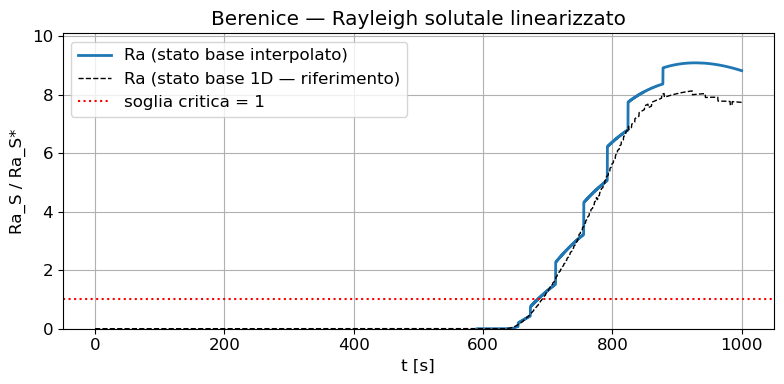

Soglia Ra superata per la prima volta a t = 684.3 s


In [23]:
Ra_result = []
for k in range(len(result['times'])):
    t  = result['times'][k]
    ki = int(np.argmin(np.abs(t_base - t)))
    c_bar  = np.interp(result['z'], z1d, c_base[:,ki])
    ph_bar = np.interp(result['z'], z1d, phi_base[:,ki])
    # Densità solo dallo stato base (fisicamente corretto nel regime lineare)
    rho_mean = density_mixture(c_bar, ph_bar)
    Ra_result.append(rayleigh_from_1d(result['z']*0.01, rho_mean))

Ra_result = np.array(Ra_result)

plt.figure(figsize=(8, 4))
plt.plot(result['times'], Ra_result, lw=2,       label='Ra (stato base interpolato)')
plt.plot(t_base,          Ra_base,   'k--', lw=1, label='Ra (stato base 1D — riferimento)')
plt.axhline(1, ls=':', c='r', label='soglia critica = 1')
plt.xlabel('t [s]'); plt.ylabel('Ra_S / Ra_S*')
plt.title('Berenice — Rayleigh solutale linearizzato')
plt.ylim(0, max(1.5, float(np.nanmax(Ra_result))*1.1 + 0.1))
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

if np.any(Ra_result > 1):
    first = np.where(Ra_result > 1)[0][0]
    print(f'Soglia Ra superata per la prima volta a t = {result["times"][first]:.1f} s')
else:
    print('Soglia Ra non superata nel tempo simulato.')

## 9. Crescita esponenziale della perturbazione

In un sistema lineare l'energia cinetica cresce come $e^{2\sigma t}$ nella fase lineare. Questo permette di stimare il tasso di crescita $\sigma$.

Tasso di crescita stimato σ ≈ 0.0264 s⁻¹
Tempo di raddoppio ≈ 26.3 s (se σ > 0 → instabilità)


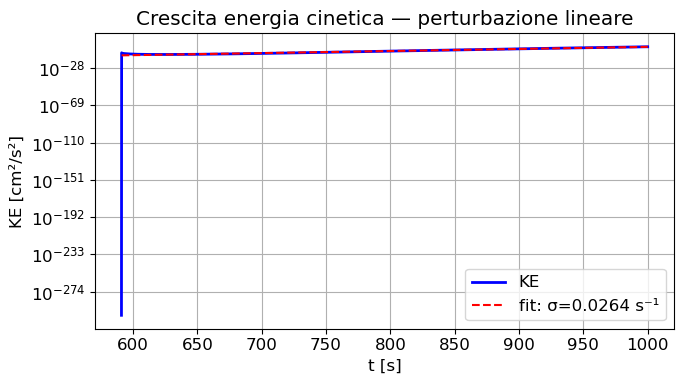

In [24]:
ke = np.array(result['ke'])
t_ke = result['times']

# Trova la fase lineare (KE > 0 e in crescita monotonaS)
mask = ke > 1e-20
if mask.sum() > 3:
    log_ke = np.log(ke[mask])
    t_fit  = t_ke[mask]
    # fit lineare su log(KE) vs t
    coeffs = np.polyfit(t_fit, log_ke, 1)
    sigma  = coeffs[0] / 2   # KE ~ e^{2 sigma t}
    print(f'Tasso di crescita stimato σ ≈ {sigma:.4f} s⁻¹')
    print(f'Tempo di raddoppio ≈ {np.log(2)/sigma:.1f} s (se σ > 0 → instabilità)')

    plt.figure(figsize=(7, 4))
    plt.semilogy(t_ke, np.maximum(ke, 1e-300), 'b', lw=2, label='KE')
    if sigma > 0:
        ke_fit = np.exp(np.polyval(coeffs, t_fit))
        plt.semilogy(t_fit, ke_fit, 'r--', lw=1.5,
                     label=f'fit: σ={sigma:.4f} s⁻¹')
    plt.xlabel('t [s]'); plt.ylabel('KE [cm²/s²]')
    plt.title('Crescita energia cinetica — perturbazione lineare')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
else:
    print('KE troppo piccola per stimare σ.')